<h1><span style="color:thistle"><b>Tasks:</span></h1> 

<h3>Remove Bridges and Electrodes</h3>
 
- With MNE dictionary code you have been send through mattermost.
- What it is: 
Basically occurence of unwanted connection between distinct electrodes which results in trend of having the same fucking numbers. Issue is mostly in gel placement(too much). Gel functions like a conduction between top of the head and electrode sensor. When there is too much it spreads and ends up connecting with another electrodes, resulting in joining the signal of two or more electrodes into one, destroing the results.
- Easiest solution to Bridges will be just removing connected electrodes alltogether.
- Usefunction Compute_bridge_electrodes: gives back bridges index of electrodes and electric distance of electrode (the bigger the better, smaller delete)
- U can use topomap to visualise removal of connected electrodes-Bridges
- When you start
      - use default value, then change the trashold for multiple results to compare >> use different names and dont delete them
      - podivej se jeste na dve funkce downsample u dvojky abz to nahodou nezohlednovalo tzodstranene matic e

Electrode plot topomap - koukni do mattermostu.
	Data musi mit shape number of channels 
	koukni jestli se dá printit dva různý regionz v jedný hlavy 
start using raw (talk atar

using plv instead of cross corelation 
	corr is really blind to rest of the code 

like 100 sampling rate 


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

import mne

<h1>EEG Electrode bridges</h1>
<h2>Compute Electrical Distance Metric</h2>

Electrical distance is the varriance of signals subtracted pairwise.
Channels mirroring other electrodes almost exactly have very low electrical distance. 
We will look for pairs that have ed almost zero

This func. is supposed to run on short time period of data that is not at the beginning due to the gel settlement ove time. SO using the last segment of the data will give the most conservative estimate.

In [2]:
path = './../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif'
subject = mne.io.read_raw_fif(path, preload=True)
montage = mne.channels.make_standard_montage("standard_1005")
subject.set_montage(montage)

#raw = subject.copy().set_eeg_reference('average', projection=False) # that shit hit the same
print(f"Computing electrode bridges for subject {path}")
#raw_data[path] = subject
#ed_data[path] = mne.preprocessing.compute_bridged_electrodes(subject)
bridged_idx, ed_matrix = mne.preprocessing.compute_bridged_electrodes(subject)

Opening raw data file ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka-roblik/AnalysisBooredEEG/Notebook/../data/C01/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.
Reading 0 ... 4807672  =      0.000 ...   600.959 secs...


/tmp/ipykernel_37026/3425097131.py:2: RuntimeWarning: This filename (./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  subject = mne.io.read_raw_fif(path, preload=True)


Computing electrode bridges for subject ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif
Local minimum 9.324623354565544 found
Bridge detected between Fp1 and Fpz
Bridge detected between Fp1 and Fp2
Bridge detected between Fp1 and F7
Bridge detected between Fp1 and F8
Bridge detected between Fp1 and FC5
Bridge detected between Fp1 and AF7
Bridge detected between Fp1 and AF3
Bridge detected between Fp1 and F5
Bridge detected between Fp1 and C5
Bridge detected between Fp1 and FT7
Bridge detected between Fp1 and AFF1
Bridge detected between Fp1 and AFz
Bridge detected between Fp1 and FFC5h
Bridge detected between Fp1 and FCC5h
Bridge detected between Fp1 and CCP5h
Bridge detected between Fp1 and AFp3h
Bridge detected between Fp1 and AFp4h
Bridge detected between Fp1 and AFF5h
Bridge detected between Fp1 and FFT7h
Bridge detected between Fp1 and FFT8h
Bridge detected between Fp1 and FTT7h
Bridge detected between Fp1 and TTP7h
Bridge detected between Fpz and Fp2
Bridge detected betwe

1.0
0.6313363517740234
0.8096695383474425
0.7431219252383509
0.3616425527823108
0.2709629007253814
0.19717393207084355
0.6551394846789719
0.7463304669615677
0.36192141656941684


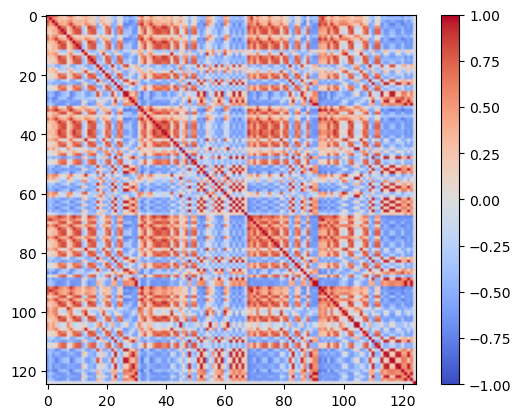

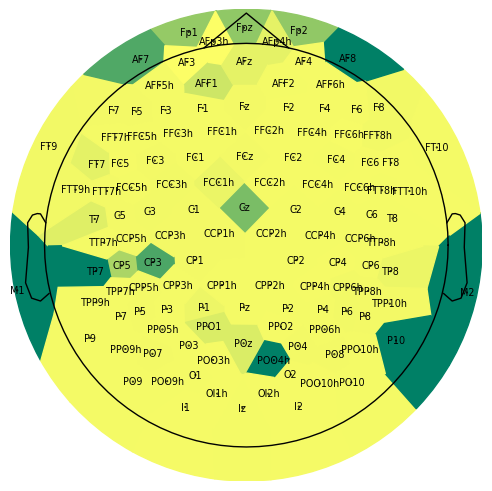

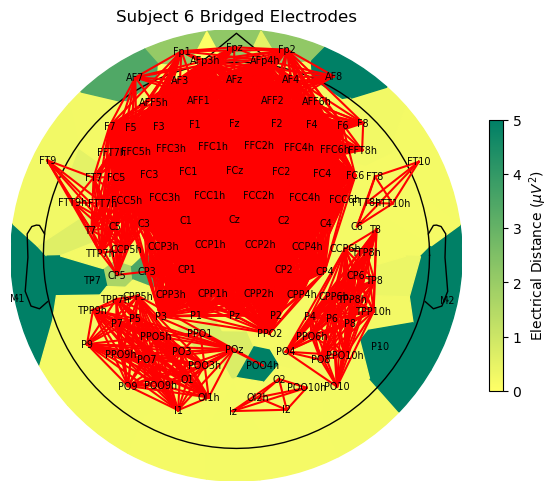

In [3]:
import numpy as np

data = subject.get_data()
corr = np.corrcoef(data)

import matplotlib.pyplot as plt
plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()

for i in range(10):
    print(np.corrcoef(data[0], data[i])[0,1])

mne.viz.plot_bridged_electrodes(
    subject.info,
    bridged_idx,
    ed_matrix,
    title="Subject 6 Bridged Electrodes",
    topomap_args=dict(vlim=(None, 5)),
)

This shit is apparently the correct result of "I love every part of me" AND the inner child connection is strong. Even tho the get_data suggest its maybe the doing of time (TODOO: where and when it happens)

<h2>Jak to zrychlit ?</h2>
Using pre function to analyse how similar are last 10 second of downsampled data of subject

Print it and then compere or decide if subject should continue

In [19]:
def plot_debug(raw_crop, data, corr, bridged_idx, ed_matrix, subject_id="unknown", seconds=10, new_freq=100):
    n_channels = data.shape[0]
    ch_names = raw_crop.ch_names

    # --- 1. Korelační matice ---
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_title(f"Korelační matice EEG kanálů\nSubject: {subject_id} | posledních {seconds}s | {new_freq}Hz", fontsize=12)
    ax.set_xlabel("Kanál #")
    ax.set_ylabel("Kanál #")
    plt.colorbar(im, ax=ax, label="Pearsonova korelace")
    plt.tight_layout()
    plt.savefig(f"corr_matrix_{subject_id}.png", dpi=150)
    plt.show()

    # --- 2. Sanity check korelací vůči kanálu 0 ---
    fig, ax = plt.subplots(figsize=(8, 3))
    sample_corrs = [np.corrcoef(data[28], data[i])[0, 1] for i in range(n_channels)]
    ax.bar(range(n_channels), sample_corrs, color='steelblue')
    ax.axhline(0.95, color='red', linestyle='--', label='bridge threshold (0.95)')
    ax.set_title(f"Korelace všech kanálů vůči '{ch_names[28]}'\nSubject: {subject_id}")
    ax.set_xlabel("Kanál index")
    ax.set_ylabel("Pearsonova korelace")
    ax.set_ylim(-1, 1)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"corr_vs_ch0_{subject_id}.png", dpi=150)
    plt.show()

    upper = sub_corr[np.triu_indices_from(sub_corr, k=1)]
    print("Max corr:", np.max(upper))

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.suptitle("Subject 6 Electrical Distance Matrix Distribution")
    ax.hist(ed_matrix[~np.isnan(ed_matrix)], bins=np.linspace(0, 500, 51))
    ax.set_xlabel(r"Electrical Distance ($\mu$$V^2$)")
    ax.set_ylabel("Count (channel pairs for all epochs)")


    # --- 3. Bridges ---
    
    if len(bridged_idx) == 0:
        print(f"✓ Žádné bridges nalezeny pro subject {subject_id}")
    else:
        #print(f"⚠ Nalezeno {len(bridged_idx)} bridge párů: {[(ch_names[a], ch_names[b]) for a, b in bridged_idx]}")
        print(f"⚠ Nalezeno {len(bridged_idx)} bridge párů") 
        fig = mne.viz.plot_bridged_electrodes(
            raw_crop.info,
            bridged_idx,
            ed_matrix,
            title=f"Bridged Electrodes — Subject: {subject_id} | threshold=0.95",
            topomap_args=dict(vlim=(None, 5)),
        )
        fig.savefig(f"bridges_{subject_id}.png", dpi=150)
        plt.show()

Opening raw data file ./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka-roblik/AnalysisBooredEEG/Notebook/../data/C01/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.
Reading 0 ... 4807672  =      0.000 ...   600.959 secs...


/tmp/ipykernel_41036/3112317100.py:6: RuntimeWarning: This filename (./../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  subject = mne.io.read_raw_fif(path, preload=True)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


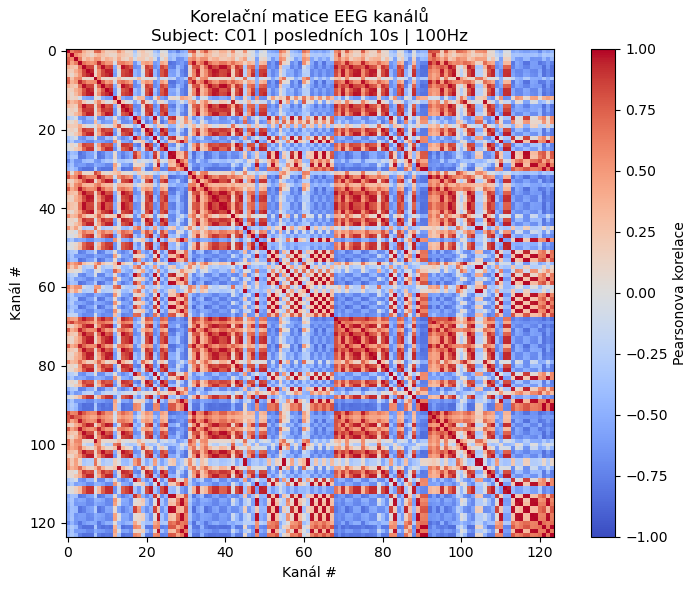

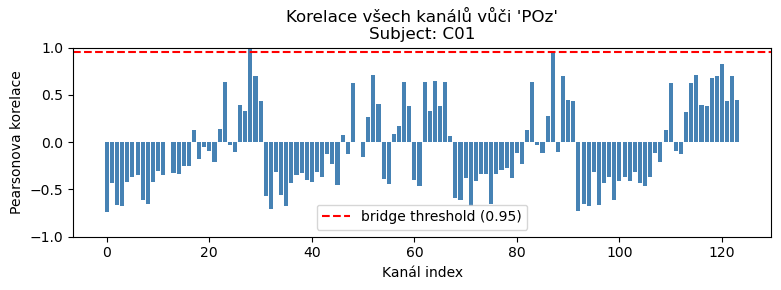

Max corr: 0.995021514106095


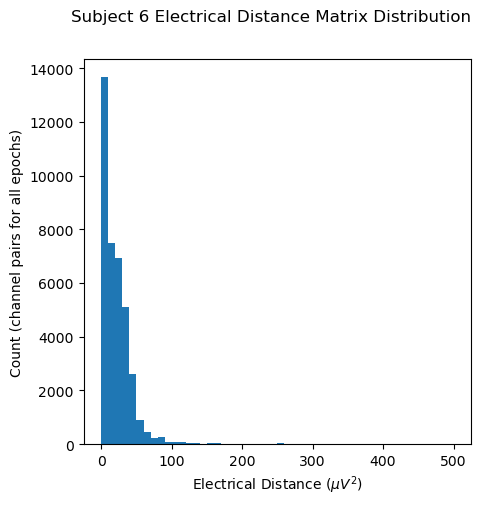

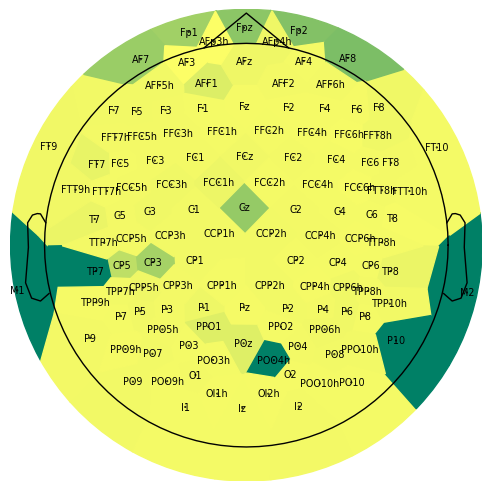

⚠ Nalezeno 1268 bridge párů


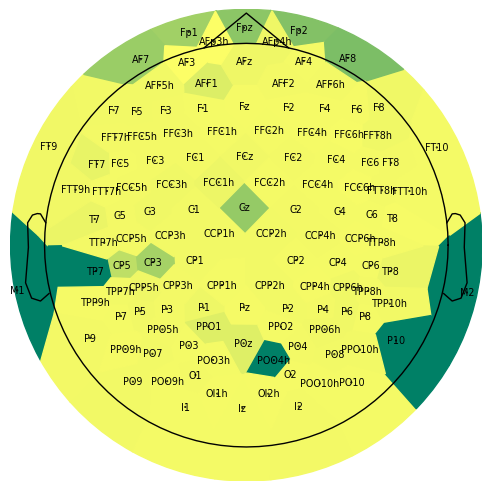

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import mne

path = './../data/C01/C01_2024-11-16_10-44-51_RS_before_ica.fif'
subject = mne.io.read_raw_fif(path, preload=True)
montage = mne.channels.make_standard_montage("standard_1005")
subject.set_montage(montage)

def compute_bridges_fast_debug(raw, seconds=10, new_freq=100, threshold=0.95):
    # 1. crop posledních X sekund
    tmax = raw.times[-1]
    tmin = tmax - seconds
    raw_crop = raw.copy().crop(tmin=tmin, tmax=tmax)
    
    # 2. jen EEG kanály
    raw_crop = raw_crop.pick_types(eeg=True)
    
    # 3. downsample
    raw_crop.resample(new_freq)
    
    # vysledky jako korelace
    data = raw_crop.get_data()
    corr = np.corrcoef(data)

    # actual bridges
    bridged_idx, ed_matrix = mne.preprocessing.compute_bridged_electrodes(
        raw_crop,
        verbose = False
        
    )

    return raw_crop, corr, data, bridged_idx, ed_matrix

SUBJECT_ID = "C01"

sub_crop, sub_corr, sub_data, sub_bridgedIdx, sub_edMatrix = compute_bridges_fast_debug(subject)
plot_debug(sub_crop, sub_data, sub_corr, sub_bridgedIdx, sub_edMatrix, subject_id=SUBJECT_ID)

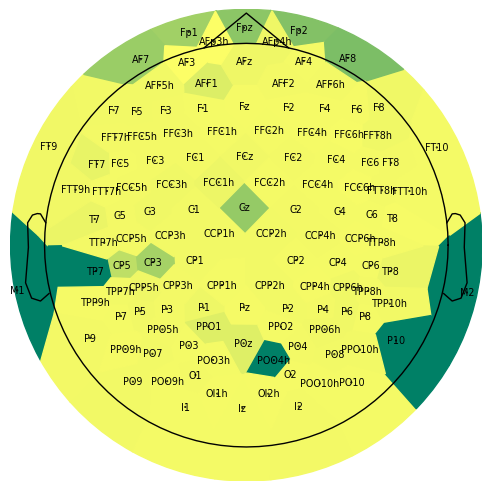

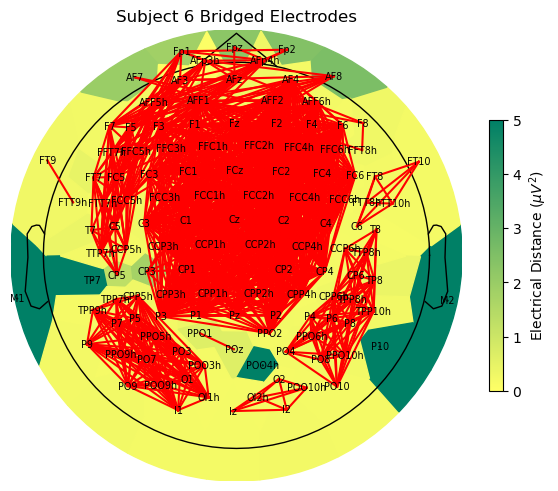

In [21]:
mne.viz.plot_bridged_electrodes(
        sub_crop.info,
        sub_bridgedIdx,
        sub_edMatrix,
        title="Subject 6 Bridged Electrodes",
        topomap_args=dict(vlim=(None, 5)),
    )

In [31]:
raw = sub_crop.copy().pick(["Cz", "C4", "P7", "P9"])

new_channels = []

for ch1, ch2 in [("Cz", "C4"), ("P7", "P9")]:
    data = raw.get_data(picks=[ch1, ch2])
    diff = data[0] - data[1]

    info = mne.create_info(
        ch_names=[f"{ch1}-{ch2}"],
        sfreq=raw.info["sfreq"],
        ch_types="eeg"
    )

    new_raw = mne.io.RawArray(diff[np.newaxis, :], info)
    new_channels.append(new_raw)

raw.add_channels(new_channels, force_update_info=True)

raw.plot(duration=20, scalings=dict(eeg=2e-4))

Creating RawArray with float64 data, n_channels=1, n_times=1000
    Range : 0 ... 999 =      0.000 ...     9.990 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=1000
    Range : 0 ... 999 =      0.000 ...     9.990 secs
Ready.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x5cc4e4f9db20) at 0x7b2a14a5c180>

<h2>Let's say the results make sense:</h2>
Proof: 

- EEG voltage over time;
- Corelation is mathematical concept of statistical measuring the strenght and direction of relat. between variables. AKA are they ran positive or negative. But can we create linear vector that touches all of them ? and if so how far away are they from that vector ?
- ED measures how different two signals are in amplitude stace::: variance (rozptyl - jak jsou hodnty v datovem souboru rozptyleny kolem průměru)


the corelation over time is saying how simmilar are visualy patterns resulting from eeg between scalp and receptor minus ears (earth). But thats just visual, no ele value what so ever 

electric distance on the other hand tells us how similar they are based on electric charge at any moment over time

rule: what corelates a lot doesnt meant that it have -small- electric distance. BUt what has small ed corelates a lot. The way I see things. THere are bridges all over at least two of them clustering parts of the brain. That results in polar oporite corelation of each electrodes. Lets take CO1s POz el. correlation comparison plot. The electrodes are clustered together. 
But I feel unsatisfied, how do I truly prove this?

In [ ]:
Algorit